In [1]:
# Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/processed/cleaned_data.csv')

figures_path = '../reports/figures'
os.makedirs(figures_path, exist_ok=True)

## 1. Descriptive Statistics

In [19]:
df.describe()

,record_id,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,...,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,no_show,readmitted_30_days,missed_appointment_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.744000,21.851000,2.884000,0.553000,0.330000,1.103000,0.85500,128.423000,78.828000,...,2.292000,1.805000,2820.500000,2412.50000,4869.600000,7971.000000,18073.600000,0.495000,0.253000,0.197133
std,288.819436,17.851474,13.040892,1.693343,0.740094,0.470448,1.885191,0.95859,15.486895,10.043669,...,1.679749,1.596723,837.694146,11140.88026,4122.515127,4629.777041,13710.258789,0.500225,0.434948,0.287691
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,85.000000,50.000000,...,0.000000,0.000000,1500.000000,0.00000,0.000000,506.000000,2954.000000,0.000000,0.000000,0.000000
25%,250.750000,33.000000,11.000000,2.000000,0.000000,0.000000,0.000000,0.00000,117.000000,72.000000,...,1.000000,1.000000,2000.000000,0.00000,2400.000000,4316.500000,11018.000000,0.000000,0.000000,0.000000
50%,500.500000,44.000000,22.000000,3.000000,0.000000,0.000000,0.000000,1.00000,128.000000,79.000000,...,2.000000,1.000000,3000.000000,0.00000,3600.000000,7680.000000,15068.500000,0.000000,0.000000,0.000000
75%,750.250000,57.000000,34.000000,4.000000,1.000000,1.000000,2.000000,1.00000,139.000000,86.000000,...,3.000000,3.000000,3500.000000,0.00000,6300.000000,11032.000000,20870.000000,1.000000,1.000000,0.333333
max,1000.000000,90.000000,44.000000,10.000000,4.000000,1.000000,9.000000,5.00000,178.000000,111.000000,...,10.000000,10.000000,4000.000000,150000.00000,27000.000000,20371.000000,179528.000000,1.000000,1.000000,1.000000


In [10]:
df.describe(include='object')

C:\Users\chalani\AppData\Local\Temp\ipykernel_8876\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,patient_id,gender,blood_group,department,diagnosis,appointment_date,appointment_status,room_type,payment_status,payment_method,disease_risk_level,bp_category,bmi_category
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,2,8,7,10,339,4,4,3,4,3,3,4
top,P10001,Male,AB-,General Medicine,Pneumonia,2025-08-08,No-Show,Not Recorded,Paid,Insurance,Medium,Elevated,Overweight
freq,1,501,136,159,115,8,495,906,668,259,469,452,402


### Descriptive Statistics
Numeric columns show plausible ranges consistent with Task 2 findings (e.g. age 
1-90, bmi 14-38.8). Categorical columns show department, diagnosis, gender etc. 
distributions - [after running, note here which category is most common in each, 
e.g. "General Medicine is the most common department"].

## 2. Distribution Analysis (Histograms)

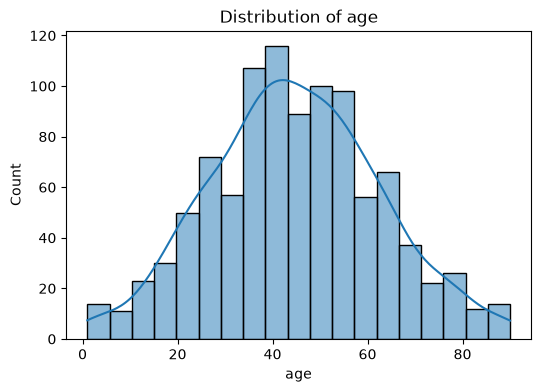

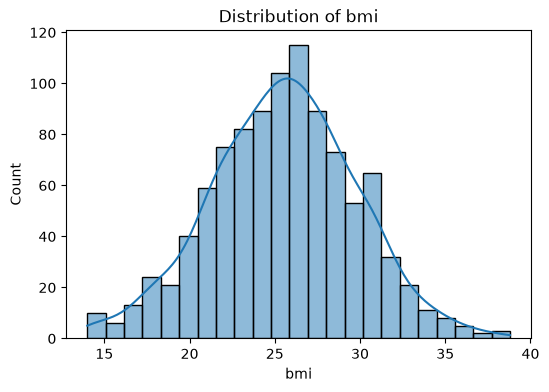

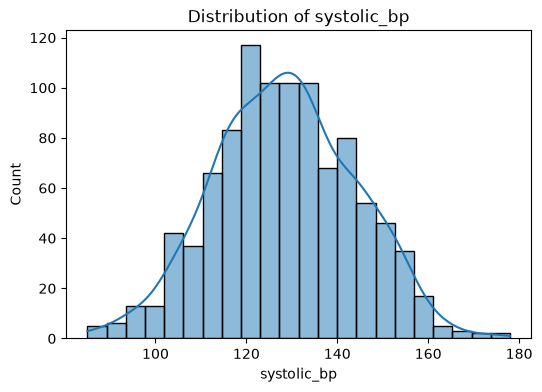

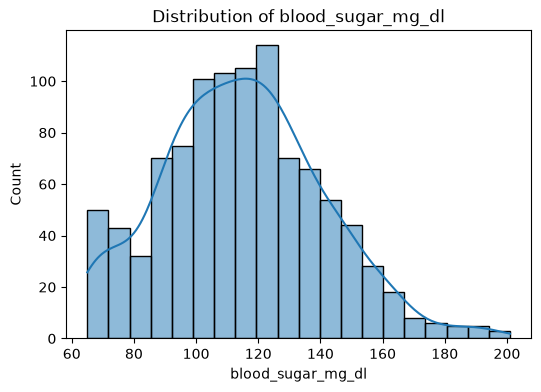

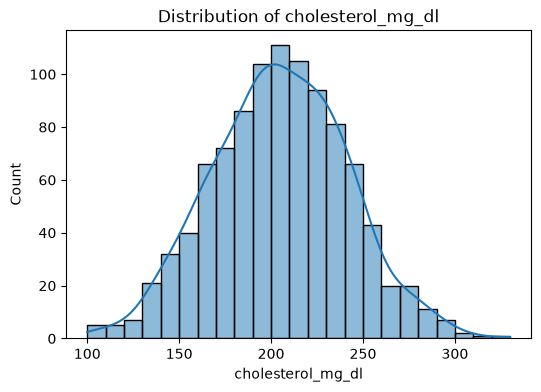

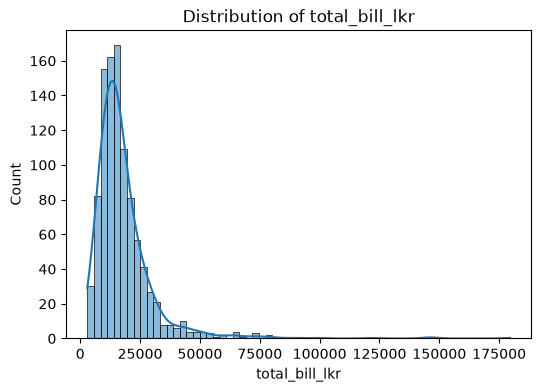

In [ ]:
numeric_cols_to_plot = ['age', 'bmi', 'systolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'total_bill_lkr']

for col in numeric_cols_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'../reports/figures/hist_{col}.png', bbox_inches='tight')
    plt.show()

### Distribution Analysis
- age: [roughly even spread / skewed young / skewed old - describe what you see]
- bmi: mostly clustered around 22-28, with the small number of low outliers 
  already identified in Task 3
- total_bill_lkr: right-skewed (most bills are lower, a smaller number are very 
  high) - expected, since admitted patients cost much more than non-admitted ones
- [add one line per column you actually plotted]

## 3. Pattern Discovery (Boxplots)

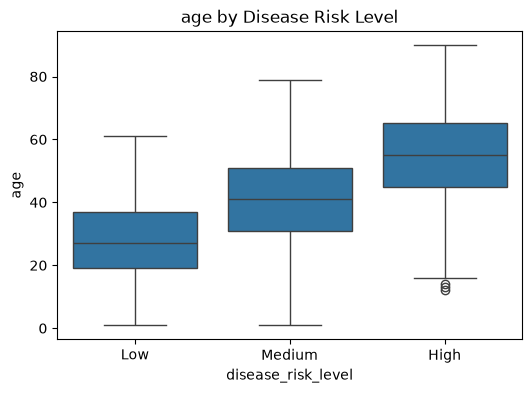

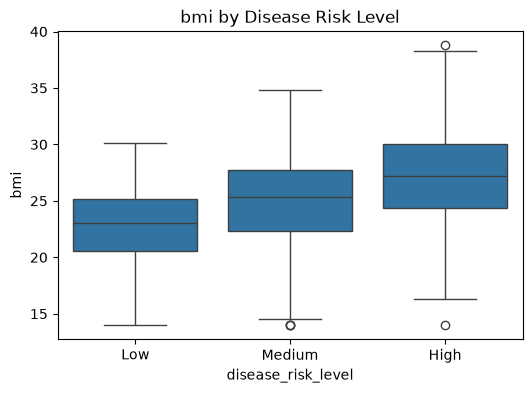

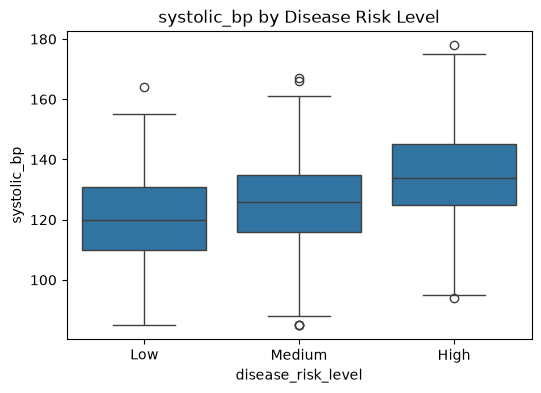

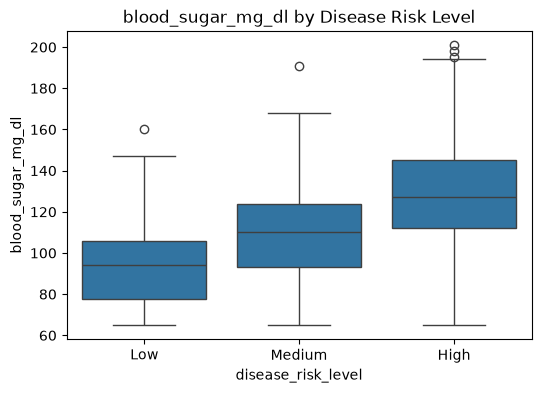

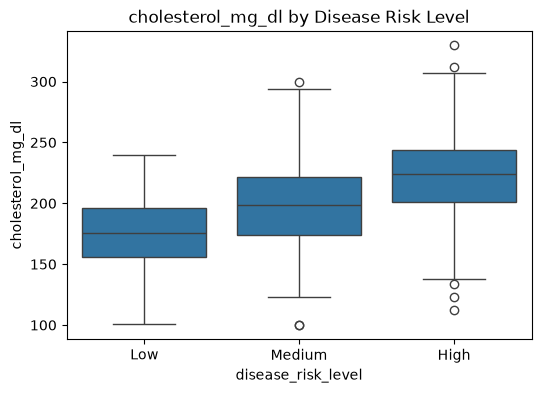

In [20]:
box_cols = ['age', 'bmi', 'systolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl']

for col in box_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='disease_risk_level', y=col, order=['Low','Medium','High'])
    plt.title(f'{col} by Disease Risk Level')
    plt.savefig(f'../reports/figures/box_{col}_by_risk.png', bbox_inches='tight')
    plt.show()

### Pattern Discovery - Boxplots by Risk Level
[For each chart, write one line, e.g.:]
- bmi: High risk patients show a visibly higher median bmi than Low risk patients
- blood_sugar_mg_dl: clear upward trend from Low to High risk groups
- age: [describe what you actually see]

## 4. Pattern Discovery (Scatterplots)

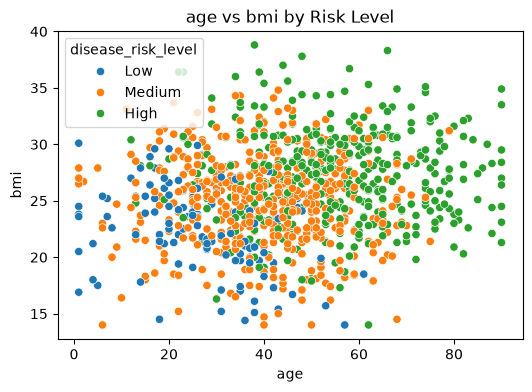

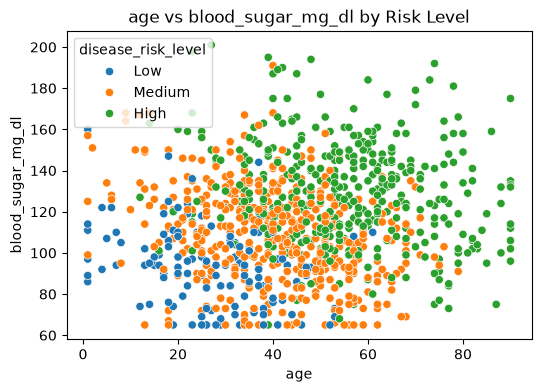

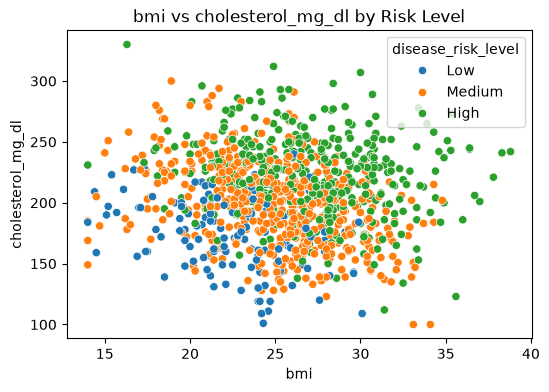

In [21]:
scatter_pairs = [('age', 'bmi'), ('age', 'blood_sugar_mg_dl'), ('bmi', 'cholesterol_mg_dl')]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='disease_risk_level', hue_order=['Low','Medium','High'])
    plt.title(f'{x_col} vs {y_col} by Risk Level')
    plt.savefig(f'../reports/figures/scatter_{x_col}_{y_col}.png', bbox_inches='tight')
    plt.show()

### Pattern Discovery - Scatterplots
[One line per pair, e.g.:]
- age vs bmi: High risk points cluster toward older age and higher bmi, though 
  overlap between groups is visible - no single variable cleanly separates risk 
  levels on its own

## 5. Correlation Analysis (Heatmap)

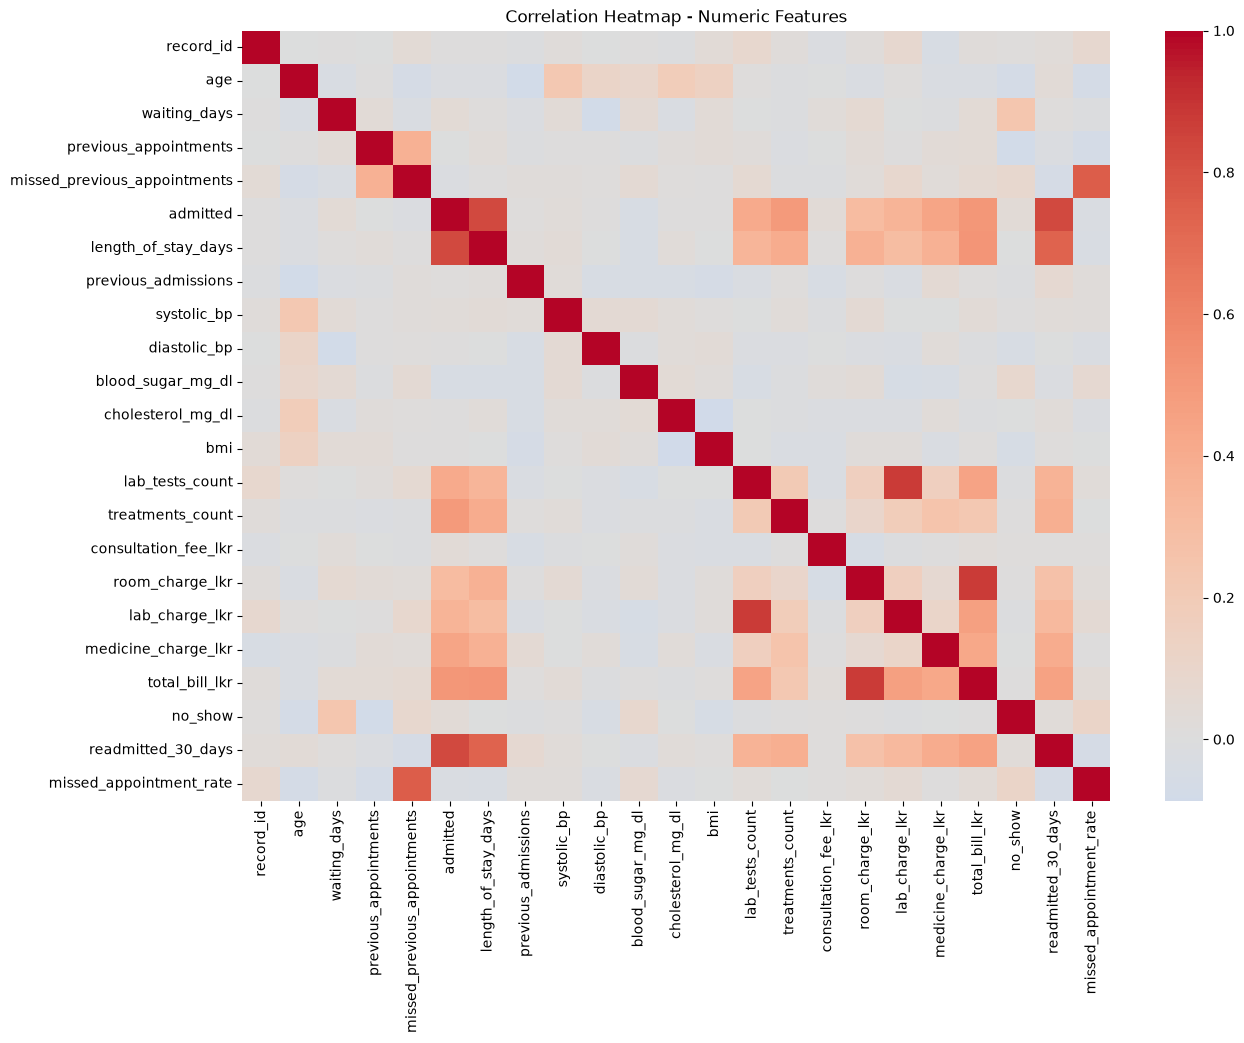

In [22]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap - Numeric Features')
plt.savefig('../reports/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Correlation Analysis
Confirms the findings from Task 3's feature selection check: admitted, 
length_of_stay_days, lab_tests_count, and billing columns are moderately 
correlated with each other (as expected, since admitted patients naturally 
have higher values across all of these). No unexpected strong correlations 
were found beyond what was already identified.

## 6. Class Distribution Chart

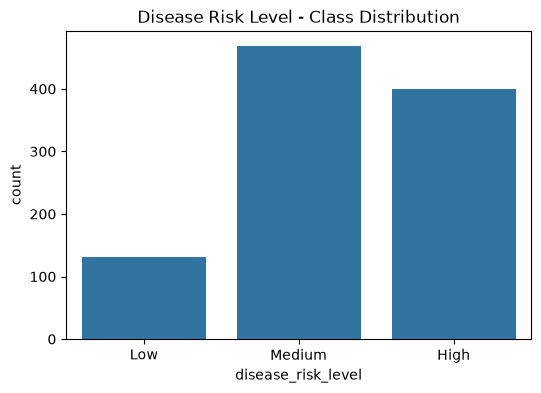

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='disease_risk_level', order=['Low','Medium','High'])
plt.title('Disease Risk Level - Class Distribution')
plt.savefig('../reports/figures/class_distribution.png', bbox_inches='tight')
plt.show()

### Class Distribution
Confirms the imbalance found in Task 2: Medium (469), High (400), Low (131). 
Low risk patients are under-represented, which will need addressing in Task 5 
(e.g. stratified sampling, class weighting) rather than being ignored.

## EDA Summary - Key Insights("Interpretation")
1. Clinical features (bmi, blood_sugar_mg_dl, cholesterol_mg_dl, systolic_bp, age) 
   show visible separation across disease_risk_level in the boxplots, consistent 
   with the correlation findings from Task 3 - these will likely be the strongest 
   predictors in Task 5.
2. Financial and operational columns (billing, admitted, length_of_stay) are 
   correlated with each other but not strongly related to disease_risk_level - 
   they reflect hospital operations, not clinical risk.
3. The target class imbalance (Low: 13.1%) is confirmed visually and needs 
   handling in modeling, not just noted and ignored.
4. No new data quality issues were discovered during EDA beyond what Task 3 
   already identified and handled.